In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel("vbg asıl veriler.xlsx")

# Log dönüşümü
df["gise_log"] = np.log1p(df["Gişe Hasılat"])
df["butce_log"] = np.log1p(df["Bütçe "])

# One-hot encoding
df = pd.get_dummies(df, columns=["Kategori"], prefix="kat")

# Hedef değişken
y = df["gise_log"]

# Özellik setleri
X_baseline = df[[  # Model 1 — sadece bütçe + kategori
    "butce_log",
    "kat_Aksiyon & Macera",
    "kat_Bilim Kurgu & Fantastik",
    "kat_Dram & Biyografi",
    "kat_Korku & Gerilim",
]]

X_duygu = df[[  # Model 2 — sadece duygu
    "Pozitif Oran (%)",
    "Negatif Oran (%)",
    "Nötr Oran (%)",
    "Ağırlıklı Duygu Skoru",
    "Toplam Yorum",
    "Toplam Beğeni",
    "Ort. Beğeni",
]]

X_tam = df[[  # Model 3 — tam özellik seti
    "butce_log",
    "kat_Aksiyon & Macera",
    "kat_Bilim Kurgu & Fantastik",
    "kat_Dram & Biyografi",
    "kat_Korku & Gerilim",
    "Pozitif Oran (%)",
    "Negatif Oran (%)",
    "Nötr Oran (%)",
    "Ağırlıklı Duygu Skoru",
    "Toplam Yorum",
    "Toplam Beğeni",
    "Ort. Beğeni",
]]

# Train/Test split — aynı split tüm modellerde
X_train_b, X_test_b, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)
X_train_d, X_test_d, _, _ = train_test_split(X_duygu, y, test_size=0.2, random_state=42)
X_train_t, X_test_t, _, _ = train_test_split(X_tam, y, test_size=0.2, random_state=42)

print(f"Eğitim seti: {len(X_train_b)} film")
print(f"Test seti:   {len(X_test_b)} film")
print("✅ Veri hazır!")

Eğitim seti: 92 film
Test seti:   24 film
✅ Veri hazır!


In [ ]:
def model_degerlendir(model, X_train, X_test, y_train, y_test, model_adi):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    # Log'dan gerçek değere çevir
    gise_gercek = np.expm1(y_test)
    gise_tahmin = np.expm1(y_pred)
    rmse_dolar  = np.sqrt(mean_squared_error(gise_gercek, gise_tahmin))

    print(f"\n{'='*50}")
    print(f"  {model_adi}")
    print(f"{'='*50}")
    print(f"  R²        : {r2:.4f}  ({r2*100:.1f}% varyansı açıklıyor)")
    print(f"  RMSE (log): {rmse:.4f}")
    print(f"  MAE  (log): {mae:.4f}")
    print(f"  RMSE ($)  : ${rmse_dolar:,.0f}")

    return {"model": model_adi, "R2": round(r2,4),
            "RMSE": round(rmse,4), "MAE": round(mae,4),
            "RMSE_dolar": round(rmse_dolar, 0),
            "tahminler": y_pred, "gercekler": y_test}

In [ ]:
sonuclar = []

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
sonuclar.append(model_degerlendir(rf, X_train_b, X_test_b, y_train, y_test, "RF — Baseline (Bütçe+Kategori)"))

rf2 = RandomForestRegressor(n_estimators=200, random_state=42)
sonuclar.append(model_degerlendir(rf2, X_train_d, X_test_d, y_train, y_test, "RF — Sadece Duygu"))

rf3 = RandomForestRegressor(n_estimators=200, random_state=42)
sonuclar.append(model_degerlendir(rf3, X_train_t, X_test_t, y_train, y_test, "RF — Tam Özellik Seti"))

# XGBoost
xgb = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
sonuclar.append(model_degerlendir(xgb, X_train_b, X_test_b, y_train, y_test, "XGB — Baseline (Bütçe+Kategori)"))

xgb2 = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
sonuclar.append(model_degerlendir(xgb2, X_train_d, X_test_d, y_train, y_test, "XGB — Sadece Duygu"))

xgb3 = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
sonuclar.append(model_degerlendir(xgb3, X_train_t, X_test_t, y_train, y_test, "XGB — Tam Özellik Seti"))

# Özet tablo
df_sonuc = pd.DataFrame([{k: v for k, v in s.items()
                           if k not in ["tahminler","gercekler","model"]}
                          for s in sonuclar])
df_sonuc.insert(0, "Model", [s["model"] for s in sonuclar])
print("\n\n📊 SONUÇ TABLOSU:")
print(df_sonuc.to_string(index=False))
df_sonuc.to_csv("model_sonuclari.csv", index=False, encoding="utf-8-sig")


  RF — Baseline (Bütçe+Kategori)
  R²        : 0.0269  (2.7% varyansı açıklıyor)
  RMSE (log): 1.5839
  MAE  (log): 1.1317
  RMSE ($)  : $172,963,973

  RF — Sadece Duygu
  R²        : 0.4216  (42.2% varyansı açıklıyor)
  RMSE (log): 1.2212
  MAE  (log): 0.9093
  RMSE ($)  : $182,696,322

  RF — Tam Özellik Seti
  R²        : 0.5958  (59.6% varyansı açıklıyor)
  RMSE (log): 1.0209
  MAE  (log): 0.7309
  RMSE ($)  : $136,530,903

  XGB — Baseline (Bütçe+Kategori)
  R²        : -0.2729  (-27.3% varyansı açıklıyor)
  RMSE (log): 1.8116
  MAE  (log): 1.2084
  RMSE ($)  : $142,429,760

  XGB — Sadece Duygu
  R²        : 0.2294  (22.9% varyansı açıklıyor)
  RMSE (log): 1.4095
  MAE  (log): 1.0695
  RMSE ($)  : $237,535,460

  XGB — Tam Özellik Seti
  R²        : 0.4068  (40.7% varyansı açıklıyor)
  RMSE (log): 1.2367
  MAE  (log): 0.9156
  RMSE ($)  : $178,272,144


📊 SONUÇ TABLOSU:
                          Model      R2   RMSE    MAE  RMSE_dolar
 RF — Baseline (Bütçe+Kategori)  0.0269 1.5

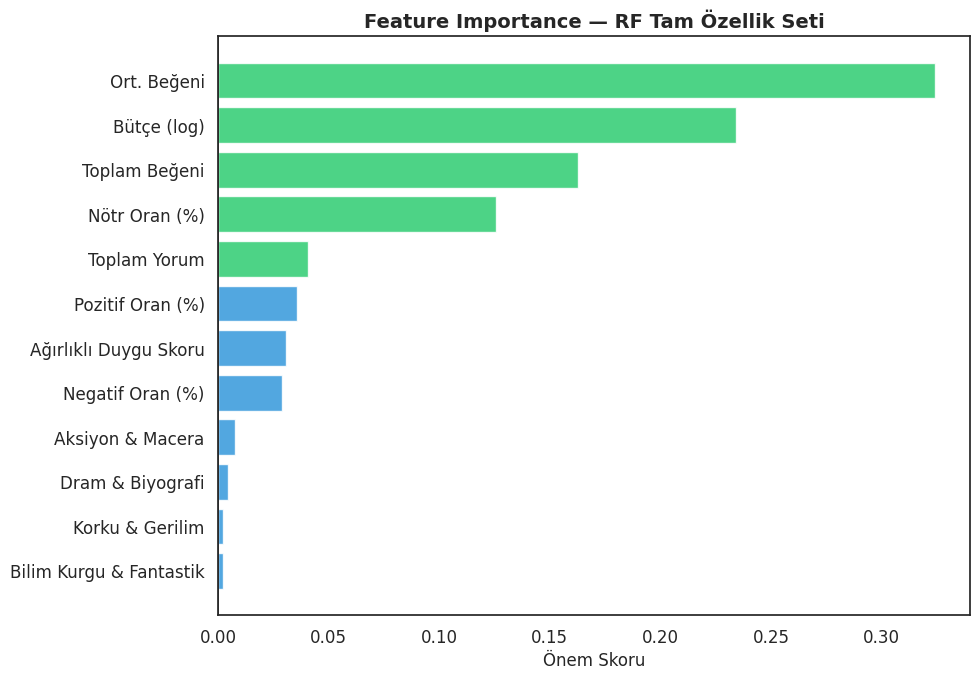

✅ feature_importance.png kaydedildi


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# En iyi model: RF Tam özellik seti
feature_names = [
    "Bütçe (log)",
    "Aksiyon & Macera",
    "Bilim Kurgu & Fantastik",
    "Dram & Biyografi",
    "Korku & Gerilim",
    "Pozitif Oran (%)",
    "Negatif Oran (%)",
    "Nötr Oran (%)",
    "Ağırlıklı Duygu Skoru",
    "Toplam Yorum",
    "Toplam Beğeni",
    "Ort. Beğeni",
]

importances = rf3.feature_importances_
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#2ECC71" if i >= len(indices)-5 else "#3498DB" for i in range(len(indices))]
ax.barh([feature_names[i] for i in indices], importances[indices], color=colors, alpha=0.85)
ax.set_xlabel("Önem Skoru", fontsize=12)
ax.set_title("Feature Importance — RF Tam Özellik Seti", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ feature_importance.png kaydedildi")

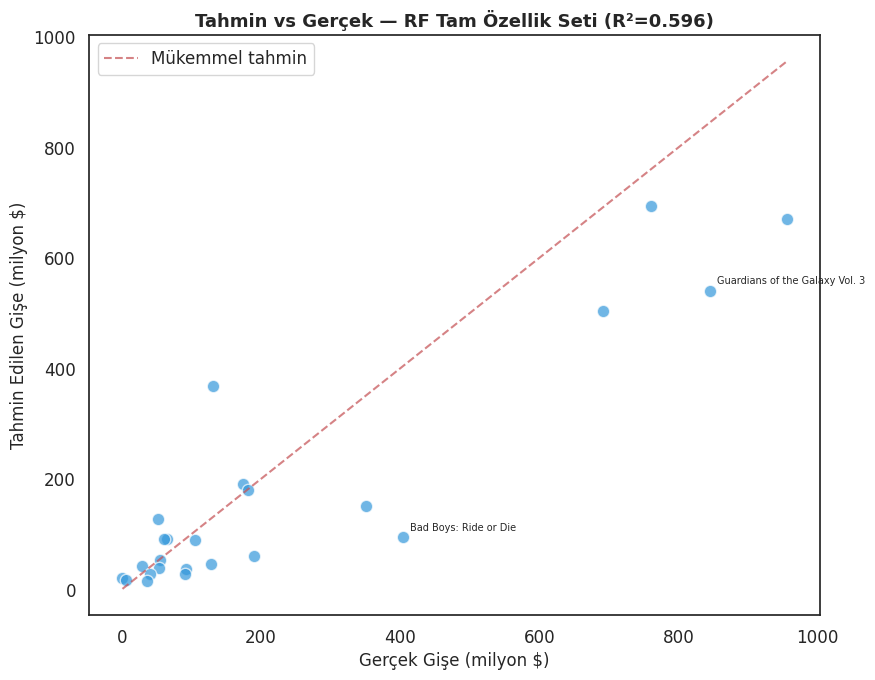

✅ tahmin_gercek.png kaydedildi


In [ ]:
# Tahminler
y_pred_tam = rf3.predict(X_test_t)

# Log'dan gerçek değere çevir (milyar dolar)
gercek = np.expm1(y_test) / 1e6  # milyon dolar
tahmin = np.expm1(y_pred_tam) / 1e6

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(gercek, tahmin, alpha=0.7, s=80,
           color="#3498DB", edgecolors="white", linewidth=1)

# Mükemmel tahmin çizgisi
min_val = min(gercek.min(), tahmin.min())
max_val = max(gercek.max(), tahmin.max())
ax.plot([min_val, max_val], [min_val, max_val],
        "r--", alpha=0.7, label="Mükemmel tahmin")

# Film isimlerini ekle
film_isimleri = df.loc[y_test.index, "Film Adı"].values
for i, (g, t, isim) in enumerate(zip(gercek, tahmin, film_isimleri)):
    if abs(g - t) > 300:  # Büyük hata yapılanları etiketle
        ax.annotate(isim, (g, t), fontsize=7,
                    xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Gerçek Gişe (milyon $)", fontsize=12)
ax.set_ylabel("Tahmin Edilen Gişe (milyon $)", fontsize=12)
ax.set_title(f"Tahmin vs Gerçek — RF Tam Özellik Seti (R²={r2_score(y_test, y_pred_tam):.3f})",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("tahmin_gercek.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ tahmin_gercek.png kaydedildi")

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Parametre grid
param_grid = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.5]
}

rf_opt = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf_opt,
    param_grid,
    cv=5,           # 5-fold cross validation
    scoring="r2",
    n_jobs=-1,      # Tüm CPU'ları kullan
    verbose=1
)

print("Optimizasyon başlıyor... (2-3 dakika sürebilir)")
grid_search.fit(X_train_t, y_train)

print(f"\n✅ En iyi parametreler:")
print(grid_search.best_params_)
print(f"\nEn iyi CV R²: {grid_search.best_score_:.4f}")

# En iyi model ile test seti değerlendirmesi
best_rf = grid_search.best_estimator_
y_pred_opt = best_rf.predict(X_test_t)
r2_opt = r2_score(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"\n📊 Optimize edilmiş model sonuçları:")
print(f"R²   : {r2_opt:.4f}  (önceki: 0.5940)")
print(f"RMSE : {rmse_opt:.4f}  (önceki: 1.0231)")
print(f"İyileşme: {(r2_opt - 0.5940)*100:.1f} puan")

# Cross validation skoru
cv_scores = cross_val_score(best_rf, X_tam, y, cv=5, scoring="r2")
print(f"\nCross Validation R² skoru:")
print(f"Ortalama: {cv_scores.mean():.4f}")
print(f"Std:      {cv_scores.std():.4f}")
print(f"Skorlar:  {[round(s,4) for s in cv_scores]}")

Optimizasyon başlıyor... (2-3 dakika sürebilir)
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✅ En iyi parametreler:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

En iyi CV R²: 0.2163

📊 Optimize edilmiş model sonuçları:
R²   : 0.5684  (önceki: 0.5940)
RMSE : 1.0549  (önceki: 1.0231)
İyileşme: -2.6 puan

Cross Validation R² skoru:
Ortalama: 0.3654
Std:      0.1795
Skorlar:  [np.float64(0.3885), np.float64(0.5567), np.float64(0.5471), np.float64(0.2465), np.float64(0.0881)]


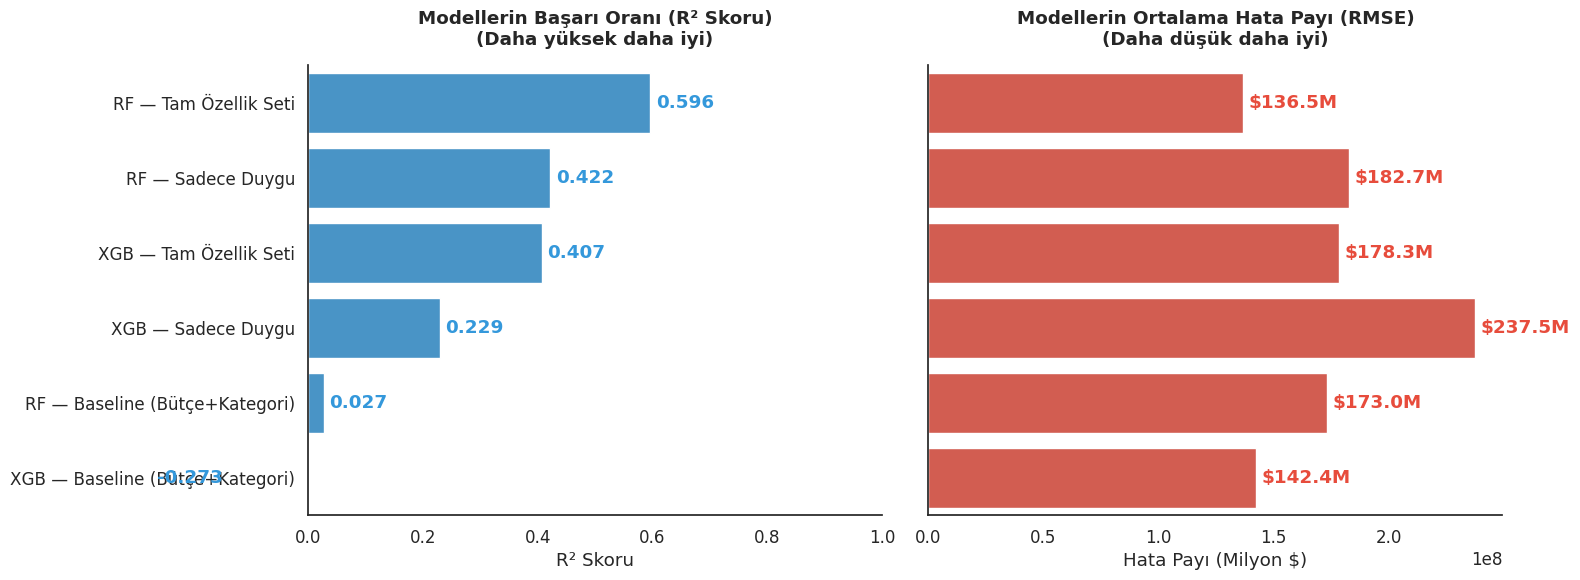

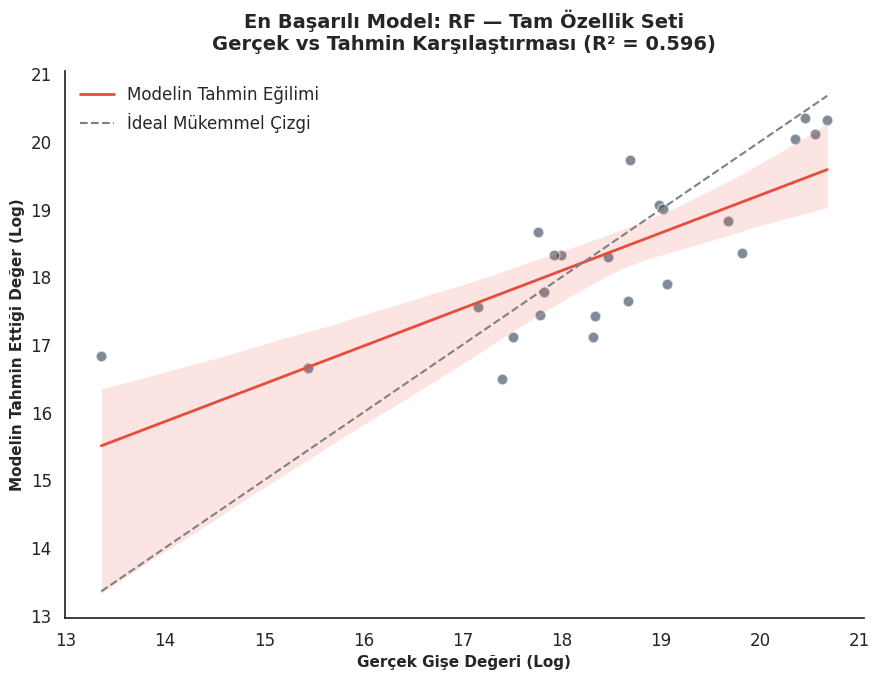

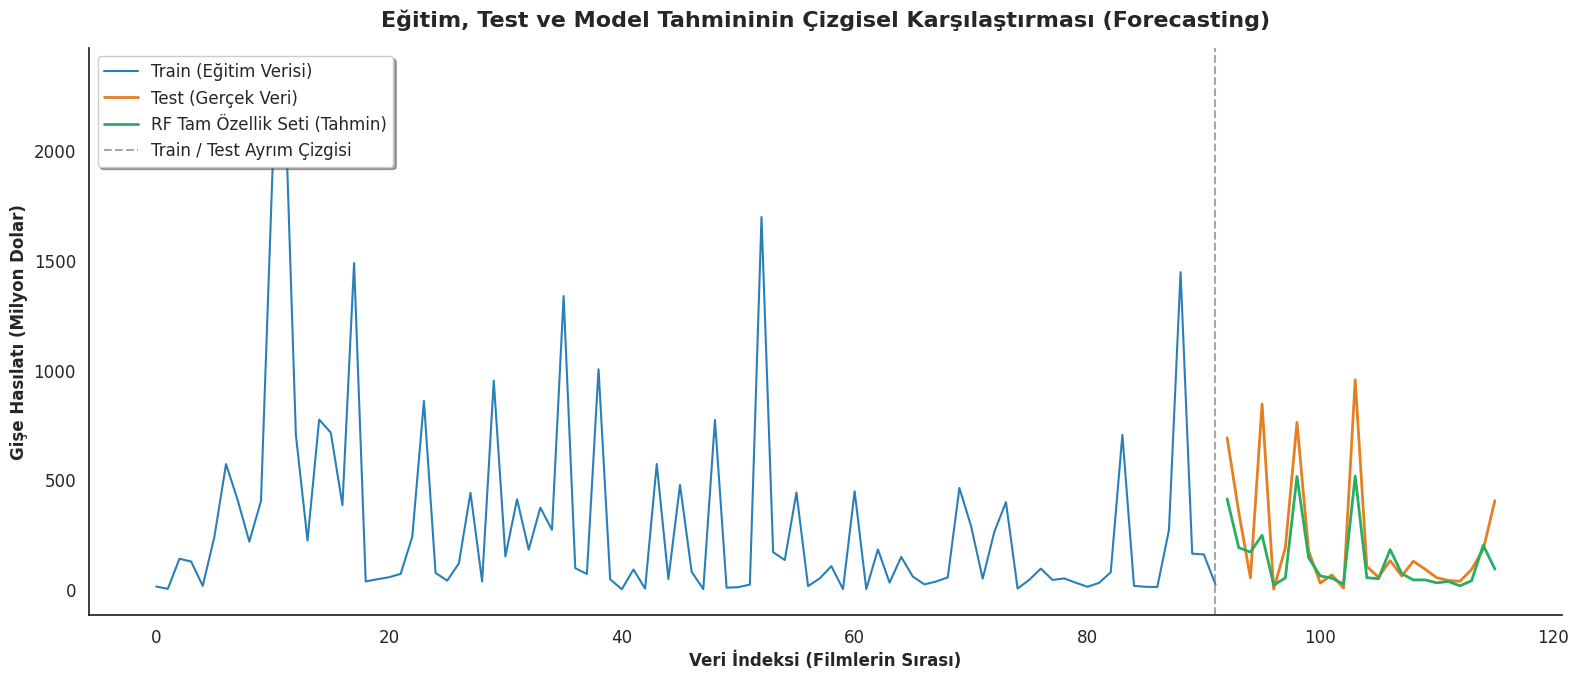

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Daha sade, arka plansız (minimal) bir estetik tema
sns.set_theme(style="white", font_scale=1.1)

# Renk paleti
color_r2 = "#3498db"   # Temiz Mavi
color_rmse = "#e74c3c" # İnce Kırmızı

# Verileri çekelim
modeller = df_sonuc["Model"].tolist()
r2_degerleri = df_sonuc["R2"].tolist()
rmse_dolar_degerleri = df_sonuc["RMSE_dolar"].tolist()

# Modelleri R2 skoruna göre büyükten küçüğe sıralayalım ki grafik estetik dursun
sorted_indices = np.argsort(r2_degerleri)[::-1]
modeller_sorted = [modeller[i] for i in sorted_indices]
r2_sorted = [r2_degerleri[i] for i in sorted_indices]
rmse_sorted = [rmse_dolar_degerleri[i] for i in sorted_indices]

# =========================================================================
# 1. GRAFİK: MODELLERİN R² VE RMSE YAN YANA KARŞILAŞTIRMASI
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. ALT GRAFİK: R² Skoru (Yatay Bar Chart)
sns.barplot(x=r2_sorted, y=modeller_sorted, color=color_r2, ax=ax1)
ax1.set_title("Modellerin Başarı Oranı (R² Skoru)\n(Daha yüksek daha iyi)", fontweight="bold", pad=15)
ax1.set_xlabel("R² Skoru")
ax1.set_xlim(0, 1.0)
sns.despine(ax=ax1)

# R2 değerlerini barların yanına yazalım
for i, v in enumerate(r2_sorted):
    ax1.text(v + 0.01, i, f"{v:.3f}", va='center', fontweight='bold', color=color_r2)

# 2. ALT GRAFİK: RMSE Hata Payı (Yatay Bar Chart)
sns.barplot(x=rmse_sorted, y=modeller_sorted, color=color_rmse, ax=ax2)
ax2.set_title("Modellerin Ortalama Hata Payı (RMSE)\n(Daha düşük daha iyi)", fontweight="bold", pad=15)
ax2.set_xlabel("Hata Payı (Milyon $)")
ax2.set_ylabel("") # İsimleri tekrar yazmaya gerek yok
ax2.set_yticks([]) # Y ekseni yazilerini gizle
sns.despine(ax=ax2)

# RMSE değerlerini barların yanına yazalım (Milyon dolara çevirerek okunmasını kolaylaştıralım)
for i, v in enumerate(rmse_sorted):
    milyon_hata = v / 1_000_000
    ax2.text(v + (max(rmse_sorted)*0.01), i, f"${milyon_hata:.1f}M", va='center', fontweight='bold', color=color_rmse)

plt.tight_layout()
plt.savefig("modeller_minimal_karsilastirma.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================================================================
# 2. GRAFİK: SADECE EN İYİ MODELİN GERÇEK vs TAHMİN GRAFİĞİ (REGPLOT)
# =========================================================================
# En iyi modeli otomatik bul (R2'si en yüksek olan)
en_iyi_index = np.argmax(r2_degerleri)
en_iyi_model_adi = modeller[en_iyi_index]
en_iyi_gercek = sonuclar[en_iyi_index]["gercekler"]
en_iyi_tahmin = sonuclar[en_iyi_index]["tahminler"]
en_iyi_r2 = r2_degerleri[en_iyi_index]

plt.figure(figsize=(9, 7))

# Seaborn regplot ile hem noktaları hem de trend çizgisini (güven aralığıyla) çok şık çizeriz
sns.regplot(
    x=en_iyi_gercek,
    y=en_iyi_tahmin,
    color="#2c3e50",
    scatter_kws={"s": 60, "alpha": 0.6, "edgecolor": "white"},
    line_kws={"color": "#e74c3c", "linewidth": 2, "label": "Modelin Tahmin Eğilimi"}
)

# Mükemmel tahmin çizgisi (45 Derece - Y=X)
min_val = min(en_iyi_gercek.min(), en_iyi_tahmin.min())
max_val = max(en_iyi_gercek.max(), en_iyi_tahmin.max())
plt.plot([min_val, max_val], [min_val, max_val], color="gray", linestyle="--", linewidth=1.5, label="İdeal Mükemmel Çizgi")

plt.title(f"En Başarılı Model: {en_iyi_model_adi}\nGerçek vs Tahmin Karşılaştırması (R² = {en_iyi_r2:.3f})", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Gerçek Gişe Değeri (Log)", fontsize=11, fontweight="bold")
plt.ylabel("Modelin Tahmin Ettiği Değer (Log)", fontsize=11, fontweight="bold")
plt.legend(loc="upper left", frameon=False)

sns.despine() # Kenar çizgilerini kaldırarak temiz bir görünüm elde et
plt.tight_layout()
plt.savefig("en_iyi_model_tahmin_gercek.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================================================================
# 3. GRAFİK: TRAIN / TEST VE TAHMİN (FORECAST) ÇİZGİ GRAFİĞİ
# =========================================================================

# Değerler kodunda logaritmik (y_train, y_test) olarak tutulduğu için,
# grafikte anlamlı görünmesi adına bunları gerçek Milyon Dolar seviyesine çeviriyoruz.
train_gercek_milyon = np.expm1(y_train) / 1_000_000
test_gercek_milyon = np.expm1(y_test) / 1_000_000

# En iyi modelin (best_rf) test seti tahminlerini de Milyon Dolara çevirelim
test_tahmin_milyon = np.expm1(best_rf.predict(X_test_t)) / 1_000_000

# X ekseni için verileri yan yana dizecek bir indeks (film sırası) oluşturalım
x_train = np.arange(len(train_gercek_milyon))
x_test = np.arange(len(train_gercek_milyon), len(train_gercek_milyon) + len(test_gercek_milyon))

plt.figure(figsize=(16, 7))

# Çizgileri çizelim (Renkleri gönderdiğin görsele uygun seçtim)
plt.plot(x_train, train_gercek_milyon, label='Train (Eğitim Verisi)', color='#2980b9', linewidth=1.5)
plt.plot(x_test, test_gercek_milyon, label='Test (Gerçek Veri)', color='#e67e22', linewidth=2)
plt.plot(x_test, test_tahmin_milyon, label='RF Tam Özellik Seti (Tahmin)', color='#27ae60', linewidth=2)

# Görseli akademik yapmak için araya bir dikey "kesik çizgi" atalım
plt.axvline(x=len(train_gercek_milyon)-1, color='gray', linestyle='--', alpha=0.7, label='Train / Test Ayrım Çizgisi')

plt.title('Eğitim, Test ve Model Tahmininin Çizgisel Karşılaştırması (Forecasting)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Veri İndeksi (Filmlerin Sırası)', fontsize=12, fontweight='bold')
plt.ylabel('Gişe Hasılatı (Milyon Dolar)', fontsize=12, fontweight='bold')

plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
sns.despine() # Grafik kenarlıklarını silip temiz bir görüntü yaratır

plt.tight_layout()
plt.savefig("train_test_forecast_cizgi_grafik.png", dpi=200, bbox_inches="tight")
plt.show()
